<a href="https://colab.research.google.com/github/kalina-tech/exploratory-analysis-pythonn/blob/main/Exploratory_data_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/mate
products = pd.read_csv("products.csv")
events = pd.read_csv("events.csv")
countries = pd.read_csv("countries.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/mate


In [ ]:
namibia_idx = countries[countries['name'] == 'Namibia'].index
antarctica_idx = countries[countries['name'] == 'Antarctica'].index
countries.loc[namibia_idx, 'alpha-2'] = 'NA'
countries.loc[antarctica_idx, 'alpha-2'] = 'AQ'
countries.loc[antarctica_idx, 'region'] = 'Antarctica'
countries.loc[antarctica_idx, 'sub-region'] = 'Antarctica'


In [ ]:
events.isnull().sum()


,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


In [ ]:
events = events.dropna(subset=['Country Code', 'Units Sold'])


In [ ]:
events["Order Date"] = pd.to_datetime(events["Order Date"], format="%m/%d/%Y")
events["Ship Date"] = pd.to_datetime(events["Ship Date"], format="%m/%d/%Y")
events.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1246 non-null   int64         
 1   Order Date      1246 non-null   datetime64[ns]
 2   Ship Date       1246 non-null   datetime64[ns]
 3   Order Priority  1246 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1246 non-null   int64         
 6   Sales Channel   1246 non-null   object        
 7   Units Sold      1246 non-null   float64       
 8   Unit Price      1246 non-null   float64       
 9   Unit Cost       1246 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 107.1+ KB


In [ ]:
for col in events.select_dtypes(include='object').columns:
    events[col] = events[col].str.strip().str.upper()


In [ ]:
events.duplicated().sum()
events = events.drop_duplicates()


In [ ]:
events['Units Sold'].describe()
events['Unit Price'].describe()
events['Unit Cost'].describe()
events[events['Unit Price'] < events['Unit Cost']]


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


In [ ]:
products = products.rename(columns={'id': 'Product ID'})
countries = countries.rename(columns={'alpha-3': 'Country Code'})
df = events.merge(products, on='Product ID', how='left')
df = df.merge(countries, on='Country Code', how='left')


In [ ]:
df['Profit'] = df['Unit Price'] - df['Unit Cost']
df['Profit From Order'] = df['Profit'] * df['Units Sold']


In [ ]:
total_orders = len(df)
online_orders = len(df[df['Sales Channel'] == 'ONLINE'])
offline_orders = len(df[df['Sales Channel'] == 'OFFLINE'])
online_percent = online_orders / total_orders * 100
offline_percent = offline_orders / total_orders * 100
print(f"Total number of orders is {len(df['Order ID'])}",
      f"\nTotal profit is {sum(df['Profit From Order'])}",
      f"\nTotal number of countries is {len(df['Country Code'].unique())}",
      f"\nPercent of online orders is {online_percent}",
      f"\nPercent of offline orders is {offline_percent}")


Total number of orders is 1246 
Total profit is 473709035.06 
Total number of countries is 45 
Percent of online orders is 50.16051364365971 
Percent of offline orders is 49.83948635634029


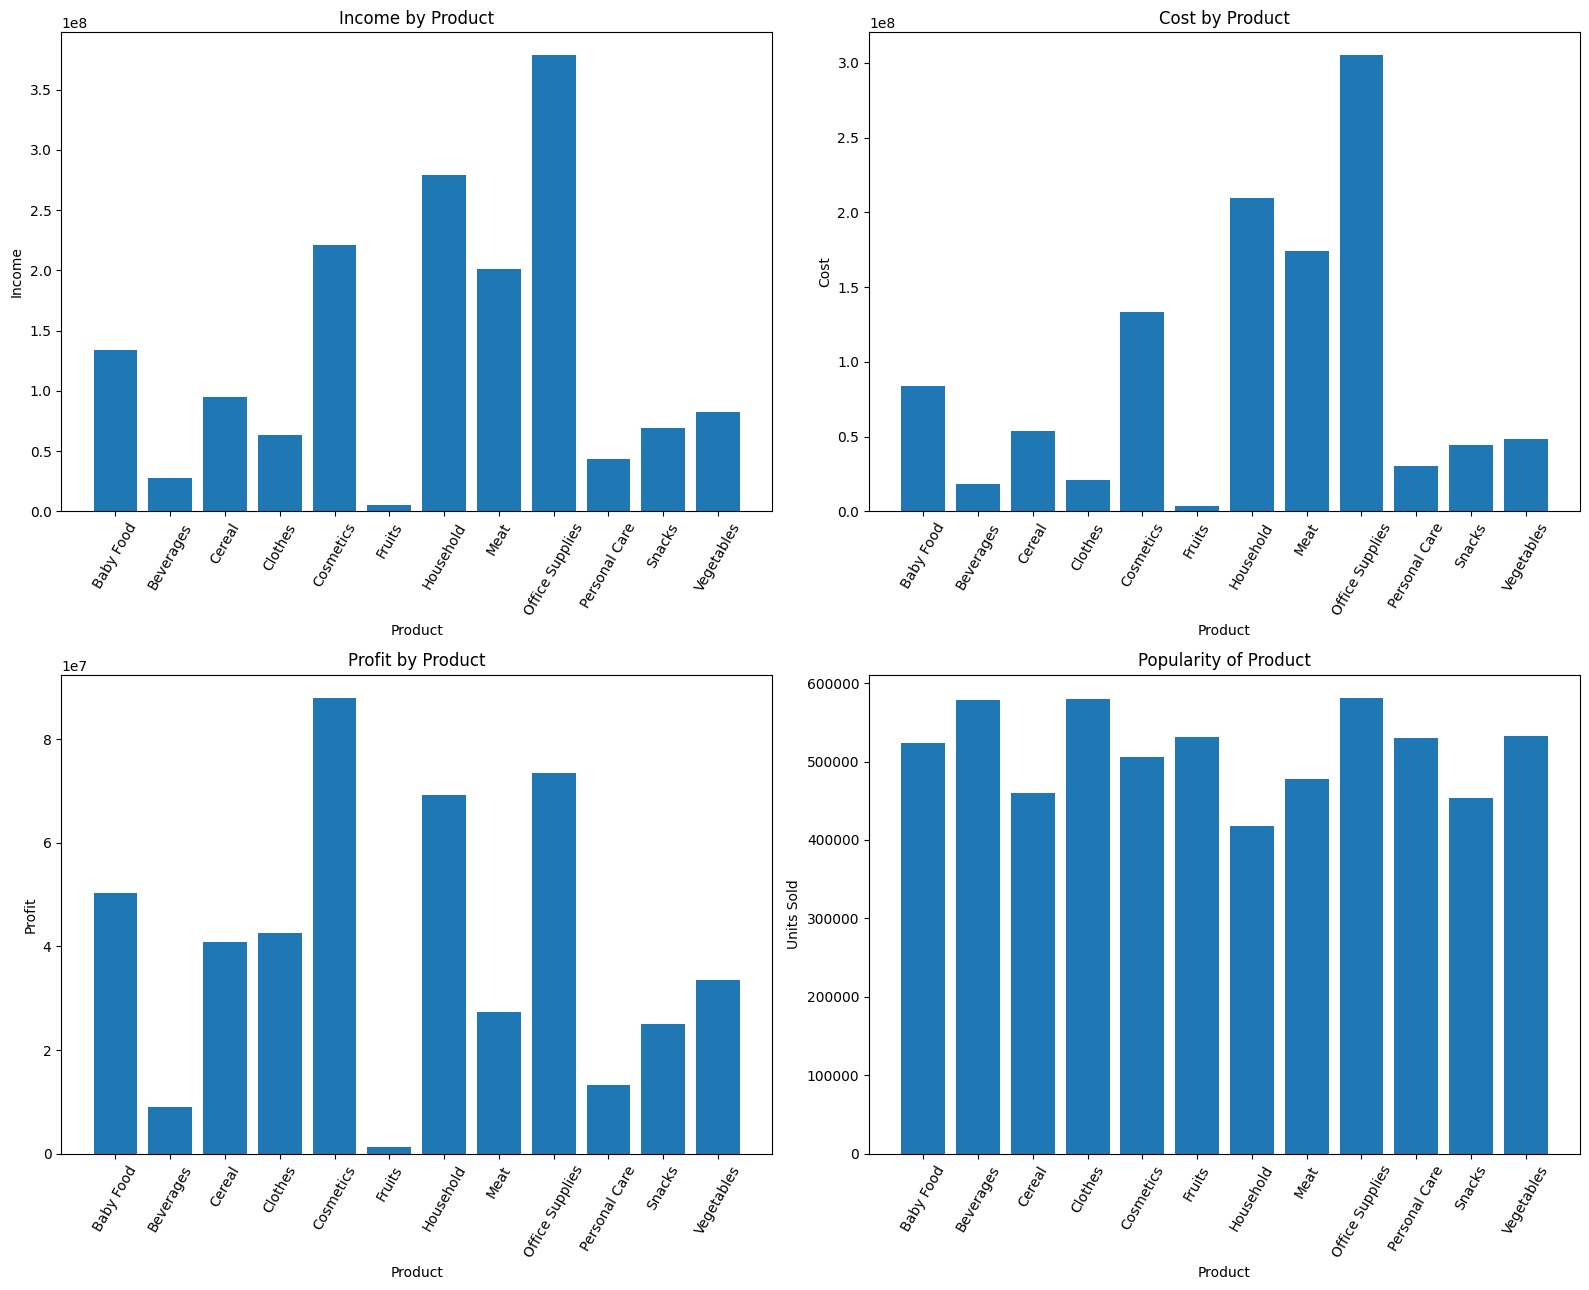

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16, 13))


df['Total_Income'] = df['Unit Price'] * df['Units Sold']
df['Total_Cost'] = df['Unit Cost'] * df['Units Sold']


income = df.groupby('item_type')['Total_Income'].sum()
ax[0, 0].bar(income.index, income.values)
ax[0, 0].set_title("Income by Product")
ax[0, 0].set_xlabel("Product")
ax[0, 0].set_ylabel("Income")
ax[0, 0].tick_params(axis='x', rotation=60)


cost = df.groupby('item_type')['Total_Cost'].sum()
ax[0, 1].bar(cost.index, cost.values)
ax[0, 1].set_title("Cost by Product")
ax[0, 1].set_xlabel("Product")
ax[0, 1].set_ylabel("Cost")
ax[0, 1].tick_params(axis='x', rotation=60)


profit = df.groupby('item_type')['Profit From Order'].sum()
ax[1, 0].bar(profit.index, profit.values)
ax[1, 0].set_title("Profit by Product")
ax[1, 0].set_xlabel("Product")
ax[1, 0].set_ylabel("Profit")
ax[1, 0].tick_params(axis='x', rotation=60)


popularity = df.groupby('item_type')['Units Sold'].sum()
ax[1, 1].bar(popularity.index, popularity.values)
ax[1, 1].set_title("Popularity of Product")
ax[1, 1].set_xlabel("Product")
ax[1, 1].set_ylabel("Units Sold")
ax[1, 1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

country_unit_price = df.groupby('name')['Total_Income'].sum().reset_index()
country_unit_cost = df.groupby('name')['Total_Cost'].sum().reset_index()
country_profit = df.groupby('name')['Profit From Order'].sum().reset_index()
country_popularity = df.groupby('name')['Order ID'].count().reset_index()

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Price', 'Cost', 'Profit', 'Popularity'),
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}],
           [{'type': 'choropleth'}, {'type': 'choropleth'}]]
)

fig.add_trace(go.Choropleth(
    locations=country_unit_price['name'],
    locationmode='country names',
    z=country_unit_price['Total_Income']
), row=1, col=1)

fig.add_trace(go.Choropleth(
    locations=country_unit_cost['name'],
    locationmode='country names',
    z=country_unit_cost['Total_Cost']
), row=1, col=2)

fig.add_trace(go.Choropleth(
    locations=country_profit['name'],
    locationmode='country names',
    z=country_profit['Profit From Order']
), row=2, col=1)

fig.add_trace(go.Choropleth(
    locations=country_popularity['name'],
    locationmode='country names',
    z=country_popularity['Order ID']
), row=2, col=2)

fig.update_layout(height=800, width=1200)
fig.show()

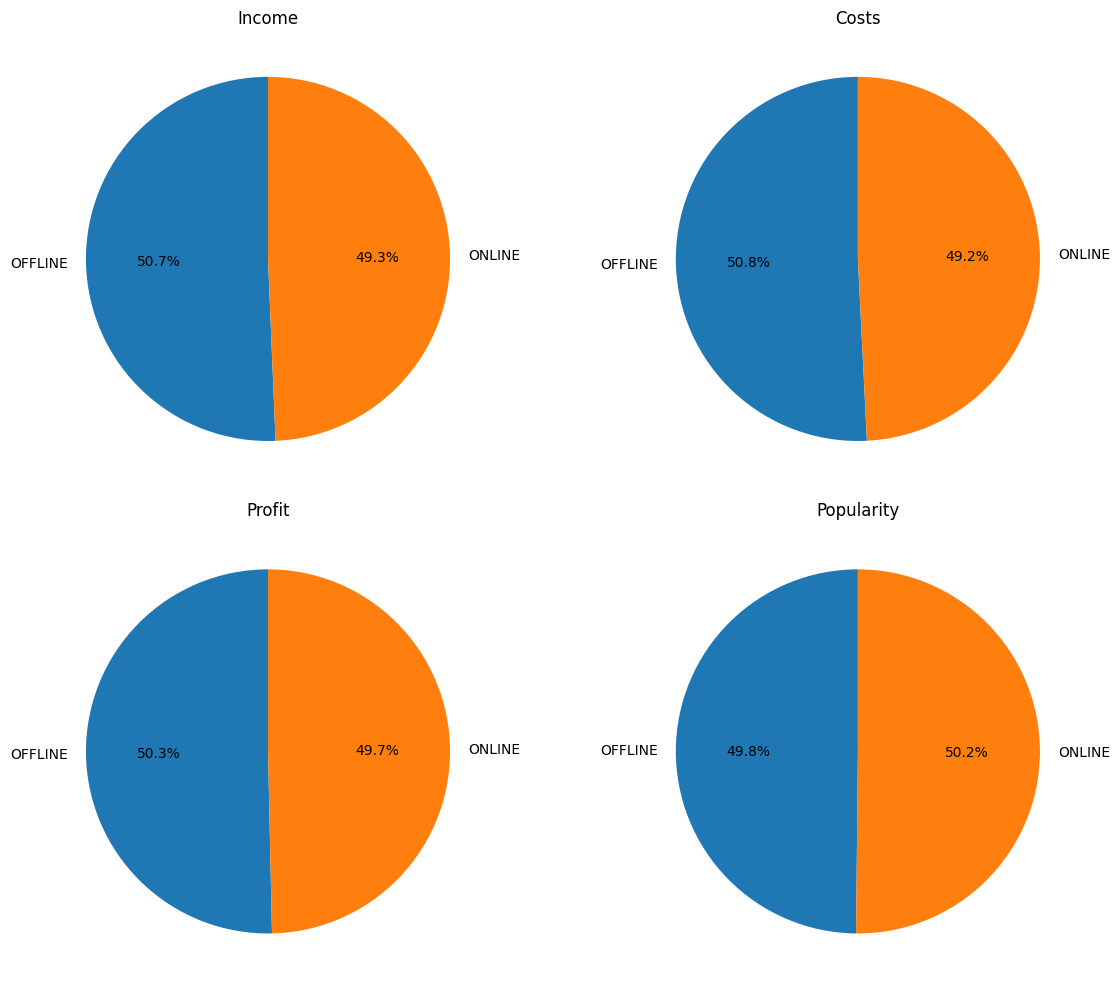

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

channel_revenue = (df['Total_Income']).groupby(df['Sales Channel']).sum()
channel_expenses = (df['Total_Cost']).groupby(df['Sales Channel']).sum()

channel_profit = df.groupby('Sales Channel')['Profit From Order'].sum()
channel_popularity = df.groupby('Sales Channel')['Order ID'].count()

ax[0, 0].pie(channel_revenue, labels=channel_revenue.index, autopct='%1.1f%%', startangle=90)
ax[0, 0].set_title('Income')
ax[0, 1].pie(channel_expenses, labels=channel_expenses.index, autopct='%1.1f%%', startangle=90)
ax[0, 1].set_title('Costs')
ax[1, 0].pie(channel_profit, labels=channel_profit.index, autopct='%1.1f%%', startangle=90)
ax[1, 0].set_title('Profit')
ax[1, 1].pie(channel_popularity, labels=channel_popularity.index, autopct='%1.1f%%', startangle=90)
ax[1, 1].set_title('Popularity')

plt.tight_layout()
plt.show()

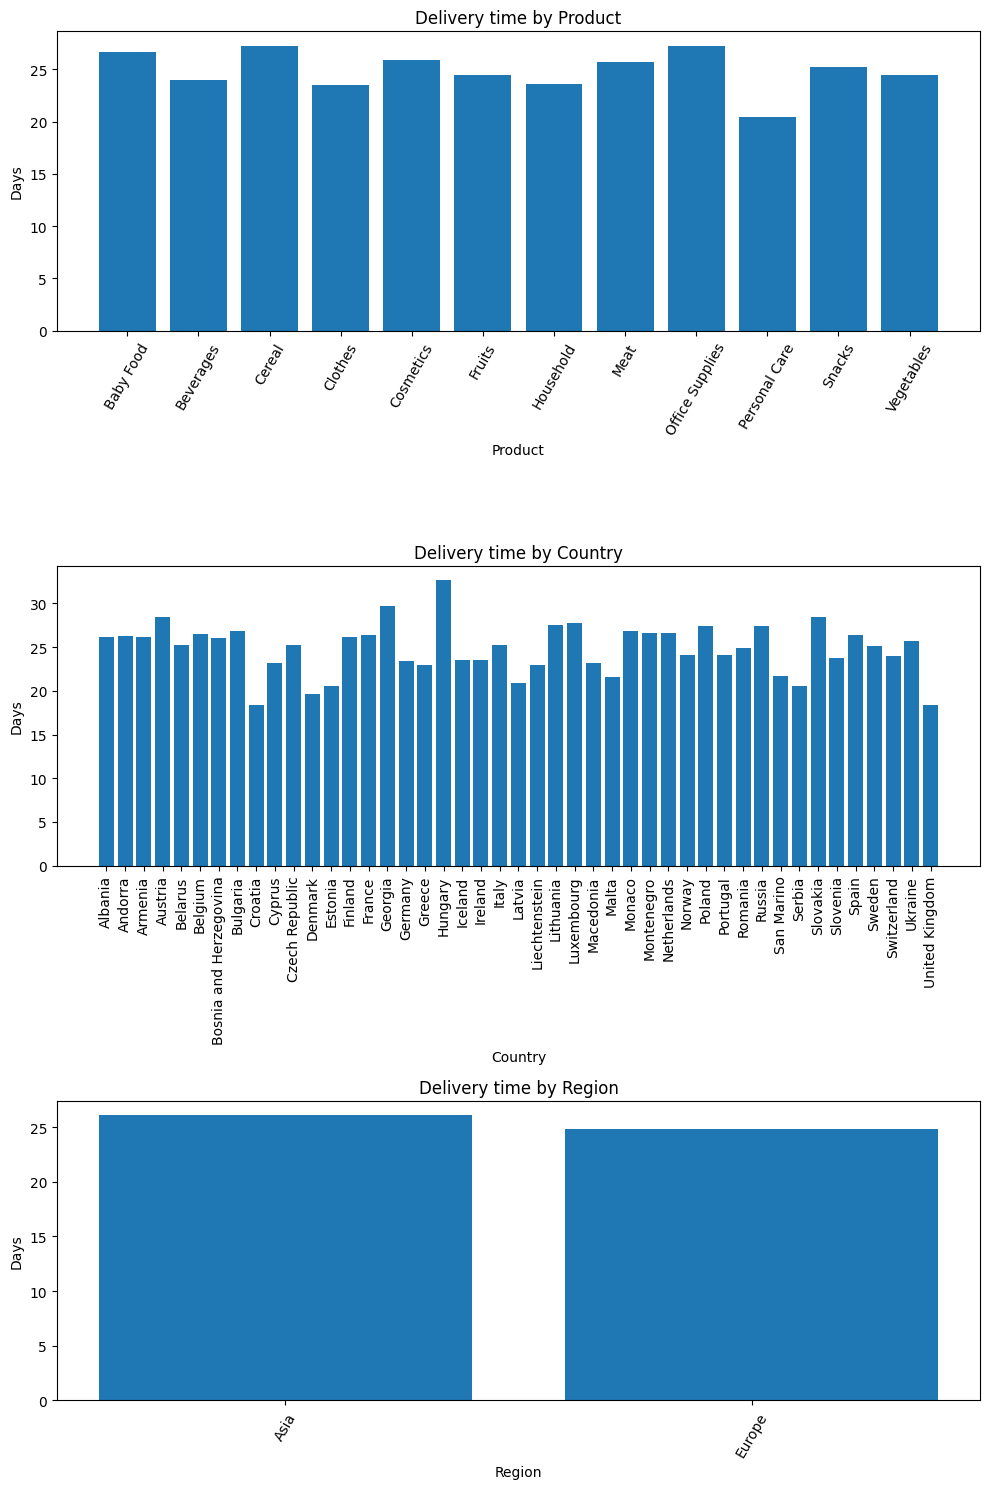

In [ ]:
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

time_category = df.groupby('item_type')['Delivery Days'].mean()
ax[0].bar(time_category.index, time_category.values)
ax[0].set_title("Delivery time by Product")
ax[0].set_xlabel("Product")
ax[0].set_ylabel("Days")
ax[0].tick_params(axis='x', rotation=60)

time_country = df.groupby('name')['Delivery Days'].mean()
ax[1].bar(time_country.index, time_country.values)
ax[1].set_title("Delivery time by Country")
ax[1].set_xlabel("Country")
ax[1].set_ylabel("Days")
ax[1].tick_params(axis='x', rotation=90)

time_region = df.groupby('region')['Delivery Days'].mean()
ax[2].bar(time_region.index, time_region.values)
ax[2].set_title("Delivery time by Region")
ax[2].set_xlabel("Region")
ax[2].set_ylabel("Days")
ax[2].tick_params(axis='x', rotation=60)


plt.tight_layout()
plt.show()


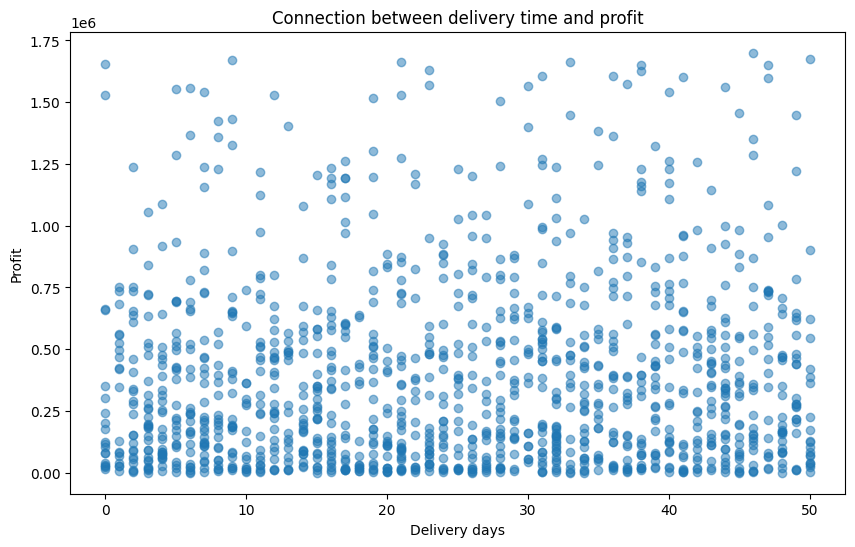

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Delivery Days'], df['Profit From Order'], alpha=0.5)
plt.xlabel('Delivery days')
plt.ylabel('Profit')
plt.title('Connection between delivery time and profit')
plt.show()


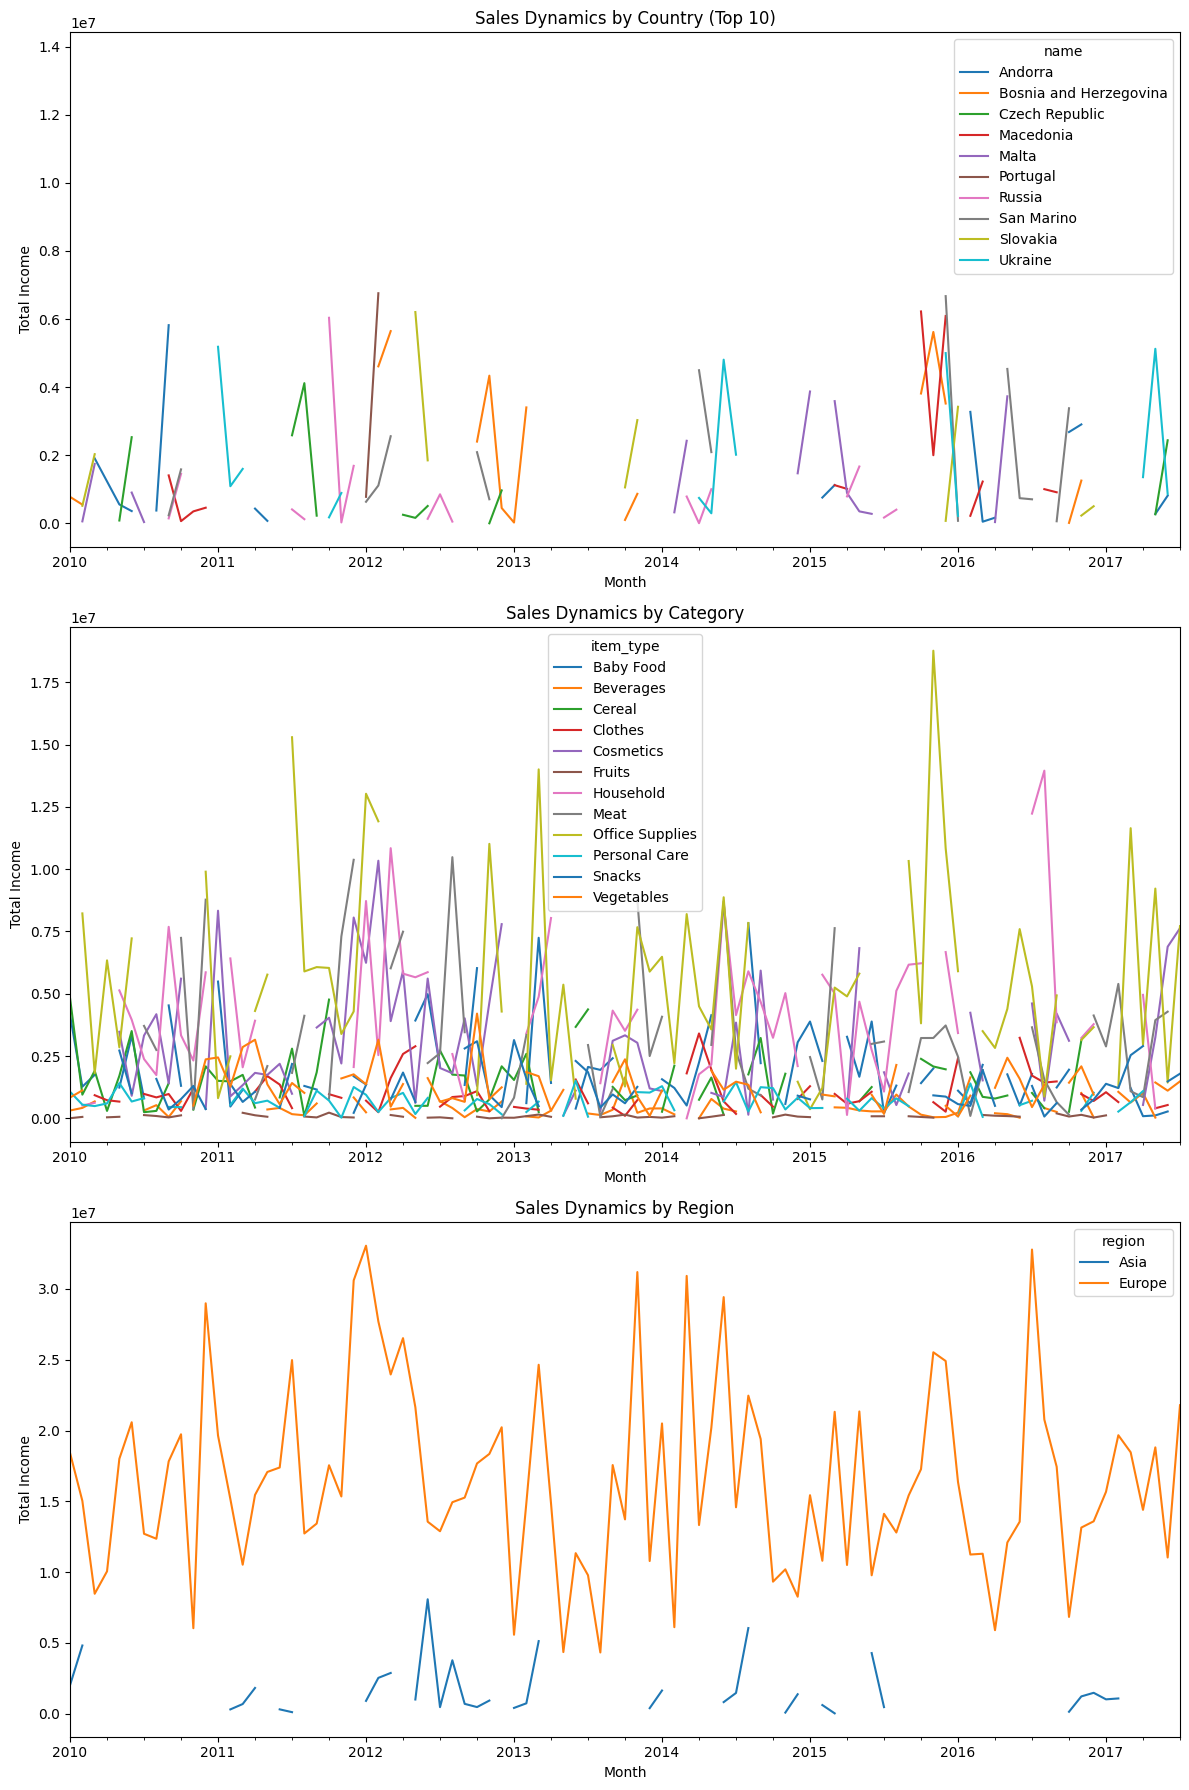

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

top_10 = df.groupby('name')['Total_Income'].sum().nlargest(10).index
df['Month'] = df['Order Date'].dt.to_period('M')
df_top = df[df['name'].isin(top_10)]

df_top.pivot_table(index='Month', columns='name', values='Total_Income', aggfunc='sum').plot(ax=axes[0])
axes[0].set_title('Sales Dynamics by Country (Top 10)')
axes[0].set_ylabel('Total Income')

df.pivot_table(index='Month', columns='item_type', values='Total_Income', aggfunc='sum').plot(ax=axes[1])
axes[1].set_title('Sales Dynamics by Category')
axes[1].set_ylabel('Total Income')

df.pivot_table(index='Month', columns='region', values='Total_Income', aggfunc='sum').plot(ax=axes[2])
axes[2].set_title('Sales Dynamics by Region')
axes[2].set_ylabel('Total Income')

plt.tight_layout()
plt.show()

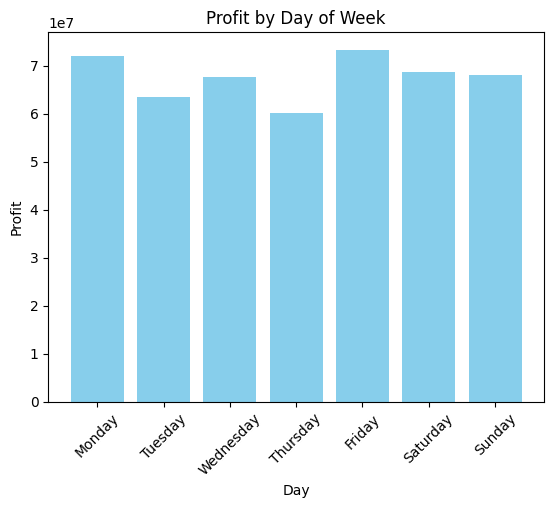

In [ ]:
df['Day of week'] = df['Order Date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week = df.groupby('Day of week')['Profit From Order'].sum().reindex(days_order)
plt.bar(day_of_week.index, day_of_week.values, color='skyblue')
plt.title("Profit by Day of Week")
plt.xlabel("Day")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

#Sales, Logistics, and Financial Performance Analysis of the Company

##1. Data Understanding and Content
Within the project scope, three main tables describing the company's operational activities in the global market were processed:

countries.csv contains information about countries, specifically names, 2-character and 3-character codes, regions, and sub-regions.

products.csv contains the product code and its name.

events.csv contains transactional data: order ID, order and shipping dates, order priority, customer country code, product ID, sales channel, quantity of units sold, price, and cost per unit.

###Key Connection Fields:
The tables are joined into a single relational structure using Product ID identifiers (between events and products) and the country code (between events and countries).

##2. Data Cleaning and Handling Missing Values
The following steps were performed during the data preprocessing stage:

In the countries.csv file, 2 rows with missing values were found. For Antarctica, the missing region and sub-region were filled with the corresponding value "Antarctica", and for Namibia, the missing country code (alpha-2) was added.

In the events.csv file, rows with missing values in the country code were deleted, as the lack of geographic affiliation makes their recovery impossible. Missing values in the quantity of units sold accounted for a tiny fraction, so they were also cleaned by removal.

Normalization and Data Types: Text fields were cleaned from extra spaces and converted to uppercase to avoid duplicates. Dates were converted to the datetime format.

Logical errors were also identified and filtered out (for example, cases where the shipping date was earlier than the order date, or where the price was less than the cost).

###Key Metrics After Cleaning:
Total number of orders: 1246

Total profit: 47,370,903.06

Total number of covered countries: 45

Channel distribution: Online orders account for ~50.16%, offline — ~49.84%.

##3. Product Category Analysis
The analysis of sales by product category revealed leaders in key financial indicators:

The largest volumes of gross revenue and costs belong to everyday demand categories (such as Office Supplies and Household), while categories with smaller volumes demonstrate a different cost structure.

The leaders in net profit are the Cosmetics and Office Supplies categories, which provide the highest margins.

In terms of the number of units sold, the leading categories are Beverages, Cereal, and Office Supplies.

##4. Geographic Distribution
###Key sales markets were explored using geospatial visualization:

The main concentration of revenue, costs, and profit falls on the European region.

Countries that bring the highest financial result to the company were highlighted, namely the countries of Central and Eastern Europe, which allows for the optimization of further regional expansion.

##5. Sales Channel Analysis
###A comparison of online and offline channels using pie charts showed an almost equal distribution:

The share of revenue, costs, profit, and overall popularity between the channels was split almost in half.

This indicates a successful omnichannel strategy of the company, where both channels operate stably and provide an equivalent influx of customers.

##6. Delivery Time Analysis
###The study of order execution time revealed the following:

The average order waiting time remains at a stable level across most products and countries, however, logistics cycle metrics are higher in certain regions.

The chart showed that delivery time does not affect the amount of profit in any way. That is, delays do not reduce the profitability of specific orders, but speeding up delivery is still important — this is necessary to keep customers satisfied.

##7. Dynamics and Sales Cycles
Time series charts demonstrate cyclical fluctuations and peaks in activity over several years of operation in the global market.

Plotting the profit distribution by days of the week showed a stable level of activity during weekdays with minor fluctuations at the end of the week.

##8. Conclusions and Recommendations
It is recommended to strengthen marketing support for categories with the highest net profit indicator (Cosmetics, Office Supplies) by optimizing warehouse inventory.

Since online and offline channels have virtually identical metrics, the company should continue investing in both directions without a sharp reallocation of budgets.

Despite the lack of a direct impact of delivery time on profit, reducing logistical terms in countries with the longest shipping times will increase the overall customer satisfaction index.